# Select a Image input

In [1]:
import sys
sys.path.append('./cpclip_utils') 
from cpclip_utils import generate_example_image


jsonl_path = "/ssd2/letitiaz/cp_project/data/jsonFile/experimentJsonl_moa/final/val_0903.jsonl"
image_root = "/ssd2/letitiaz/cp_project/data"
compound_npz_path = "/ssd2/letitiaz/cp_project/data/jsonFile/experimentJsonl/metadata/all_compounds_embedding.npz"
drug_csv_paths = [
    "/ssd2/letitiaz/cp_project/data/jsonFile/experimentJsonl/metadata/bbbc021_drugExperiment.csv",
    "/ssd2/letitiaz/cp_project/data/jsonFile/experimentJsonl/metadata/cpjump_drugExperiment.csv",
    "/ssd2/letitiaz/cp_project/data/jsonFile/experimentJsonl/metadata/rxrx3_drugExperiment.csv"
]
save_dir = "/ssd2/letitiaz/cp_project/code/open-clip/tests/example_images"

generate_example_image(
    jsonl_path=jsonl_path,
    image_root=image_root,
    compound_npz_path=compound_npz_path,
    drug_csv_paths=drug_csv_paths,
    save_dir=save_dir
)

/ssd2/letitiaz/miniconda3/envs/vistaprofilerclip/lib/python3.9/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]



=== Final Text ===

Cell line is A549; Cells cultured in 50 µl of 2% FBS in DMEM medium, maintained
at 37°C with 5% CO₂ and 90% humidity; Image channel is Mito; The imaging
objective is 20X; The concentration is 5.0000 μM; The observation time is 24.0
hours; The perturbation compound is orantinib; The mechanism of action for this
compound is vascular endothelial growth factor receptor 2 inhibitor.

Image saved: /ssd2/letitiaz/cp_project/code/open-clip/tests/example_images/a549_mito_5dot0000_24dot0_orantinib.png


# CPCLIP - context alignment

In [2]:
import os
import sys
project_root = "/ssd2/letitiaz/cp_project/code/open-clip/src"
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import open_clip
import numpy as np
import torch

pretrained_ckpt_path = "/ssd2/letitiaz/cp_project/data/logs/ViT-B-16-experiment8/2025_09_03-06_18_00-model_ViT-B-16-lr_0.001-b_175-j_4-p_fp32/checkpoints/epoch_35.pt"
device = torch.device("cuda:7" if torch.cuda.is_available() else "cpu")

tokenizer = open_clip.get_tokenizer(
    model_name="ViT-B-16",
    context_length=256,
    tokenizer_type="hf:gpt2",  
    additional_special_tokens=['<CONC_TOKEN>', '<TIME_TOKEN>', '<COMPOUND_TOKEN>']
)

model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms(
    model_name="ViT-B-16",
    pretrained= pretrained_ckpt_path,
    precision="fp32",
    device=device,
    tokenizer=tokenizer,
    output_dict=True,
    load_weights_only=True,
    special_tokens=['<CONC_TOKEN>', '<TIME_TOKEN>', '<COMPOUND_TOKEN>'],
    use_enhanced_clip=True  
)
model.eval()
context_length = model.context_length
vocab_size = model.vocab_size

print("Model parameters:", f"{np.sum([int(np.prod(p.shape)) for p in model.parameters()]):,}")
print("Context length:", context_length)
print("Vocab size:", vocab_size)


/ssd2/letitiaz/miniconda3/envs/vistaprofilerclip/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


get_tokenizer called with model_name: ViT-B-16, context_length: 256, tokenizer_type: hf:gpt2
Added 3 special tokens to gpt2 tokenizer
   <CONC_TOKEN> -> ID: 50257
   <TIME_TOKEN> -> ID: 50258
   <COMPOUND_TOKEN> -> ID: 50259
Set pad_token to eos_token for GPT tokenizer
[Auto] Fetched special token IDs from tokenizer: {'<CONC_TOKEN>': 50257, '<TIME_TOKEN>': 50258, '<COMPOUND_TOKEN>': 50259}
Model parameters: 151,468,033
Context length: 256
Vocab size: 50260


In [3]:
from cpagent_utils import *
device = torch.device("cuda:7" if torch.cuda.is_available() else "cpu")
matcher = DrugTextImageMatcher(
    open_clip_path="/ssd2/letitiaz/cp_project/code/open-clip/src",
    pretrained_ckpt_path="/ssd2/letitiaz/cp_project/data/logs/ViT-B-16-experiment8/2025_09_03-06_18_00-model_ViT-B-16-lr_0.001-b_175-j_4-p_fp32/checkpoints/epoch_35.pt",
    image_base_dir="/ssd2/letitiaz/cp_project/data",
    text_jsonl="/ssd2/letitiaz/cp_project/data/jsonFile/experimentJsonl_moa/final/train_dedup.jsonl",
    compound_npz_path="/ssd2/letitiaz/cp_project/data/jsonFile/experimentJsonl/metadata/all_compounds_embedding.npz",
    drug_csv_paths=[
        "/ssd2/letitiaz/cp_project/data/jsonFile/experimentJsonl/metadata/bbbc021_drugExperiment.csv",
        "/ssd2/letitiaz/cp_project/data/jsonFile/experimentJsonl/metadata/cpjump_drugExperiment.csv",
        "/ssd2/letitiaz/cp_project/data/jsonFile/experimentJsonl/metadata/rxrx3_drugExperiment.csv"
    ],
    device=device
)

final_text, left_img, right_img = matcher.run("/ssd2/letitiaz/cp_project/code/open-clip/tests/example_images/mcf7_tubulin_0dot3000_24dot0_emetine.png")





get_tokenizer called with model_name: ViT-B-16, context_length: 256, tokenizer_type: hf:gpt2
Added 3 special tokens to gpt2 tokenizer
   <CONC_TOKEN> -> ID: 50257
   <TIME_TOKEN> -> ID: 50258
   <COMPOUND_TOKEN> -> ID: 50259
Set pad_token to eos_token for GPT tokenizer
[Auto] Fetched special token IDs from tokenizer: {'<CONC_TOKEN>': 50257, '<TIME_TOKEN>': 50258, '<COMPOUND_TOKEN>': 50259}


Encoding: 100%|██████████| 301/301 [00:24<00:00, 12.04it/s]



 The most matching drug condition listed as below:
----------------------------------------
Text:      Cell line is MCF7; Cells cultured in RPMI 1640 medium with 10% fetal bovine serum, 1% GlutaMAX, and 900 μg/mL G418, maintained at 37°C with 5% CO₂; Image channel is Tubulin; The imaging objective is 20X; The concentration is <CONC_TOKEN>; The observation time is <TIME_TOKEN>; The perturbation compound is <COMPOUND_TOKEN>; The mechanism of action for this compound is protein synthesis.
Time:         24 hours
Concentration:0.3000 uM
Compound:     emetine
Similarity score:   0.6378
----------------------------------------


In [5]:
experiment = f"data1"
segmenter = CellSegmentor(
    model_ckpt_path="/ssd2/letitiaz/cp_project/code/open-clip/tests/segmentor_utils/model_epoch_019.pt",
    device=device
)

pipeline_paths = {
    "DNA": "/ssd2/letitiaz/cp_project/code/open-clip/tests/cellprofiler_utils/bbbcDNAprofiler.cppipe",
    "Tubulin": "/ssd2/letitiaz/cp_project/code/open-clip/tests/cellprofiler_utils/bbbcTubulinprofiler.cppipe",
    "Actin": "/ssd2/letitiaz/cp_project/code/open-clip/tests/cellprofiler_utils/bbbcActinprofiler.cppipe",
}

extractor = CellProfilerFeatureExtractor(
    pipeline_paths=pipeline_paths,
    output_base_dir=f"/ssd2/letitiaz/cp_project/code/open-clip/tests/resoning_results/{experiment}/feature_output",
    temp_input_base_dir=f"/ssd2/letitiaz/cp_project/code/open-clip/tests/resoning_results/{experiment}/temp_input"
)

CellSamWrapper auto_resize_inputs True network_resize_roi [1024, 1024] checkpoint None


# Generate reports


 Running experiment: data1


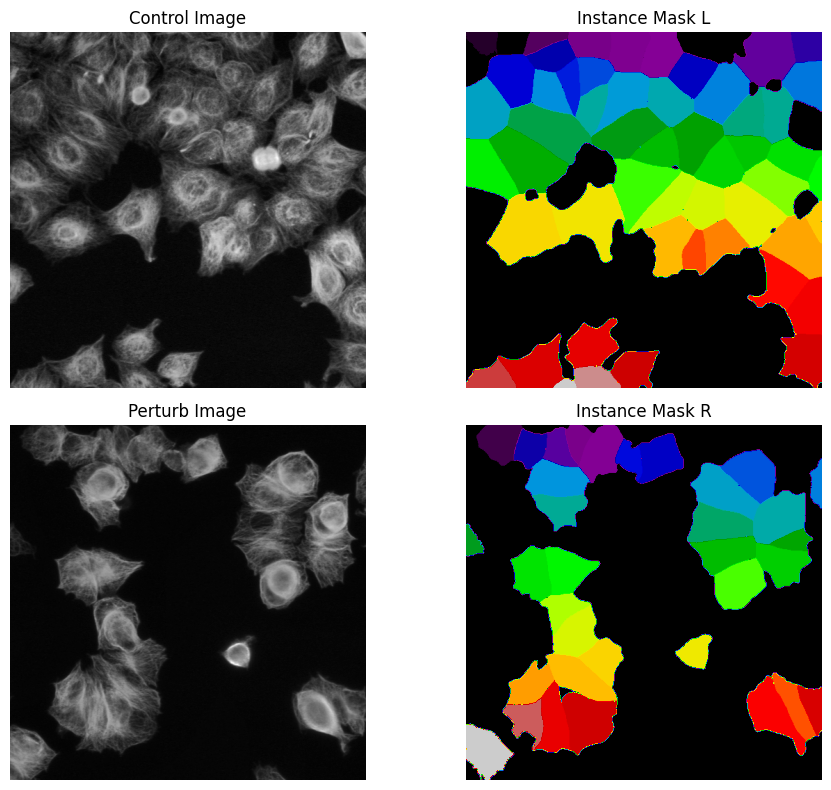


Running CellProfiler for: control | Channel: Tubulin
Image: /ssd2/letitiaz/cp_project/code/open-clip/tests/resoning_results/data1/temp_input/control/Tubulin/default/image/Tubulin/control_Tubulin.png
Mask:  /ssd2/letitiaz/cp_project/code/open-clip/tests/resoning_results/data1/temp_input/control/Tubulin/default/mask/cell/control_cell.png
Command: cellprofiler -c -r -p /ssd2/letitiaz/cp_project/code/open-clip/tests/cellprofiler_utils/bbbcTubulinprofiler.cppipe -i /ssd2/letitiaz/cp_project/code/open-clip/tests/resoning_results/data1/temp_input/control/Tubulin/default -o /ssd2/letitiaz/cp_project/code/open-clip/tests/resoning_results/data1/feature_output/control/Tubulin/default


Times reported are CPU and Wall-clock times for each module
Sat Sep 27 05:17:14 2025: Image # 1, module Images # 1: CPU_time = 0.00 secs, Wall_time = 0.00 secs
Sat Sep 27 05:17:14 2025: Image # 1, module Metadata # 2: CPU_time = 0.00 secs, Wall_time = 0.00 secs
Sat Sep 27 05:17:14 2025: Image # 1, module NamesAndTypes # 3: CPU_time = 1.26 secs, Wall_time = 0.28 secs
Sat Sep 27 05:17:14 2025: Image # 1, module Groups # 4: CPU_time = 0.00 secs, Wall_time = 0.00 secs
Sat Sep 27 05:17:14 2025: Image # 1, module MeasureImageAreaOccupied # 5: CPU_time = 0.05 secs, Wall_time = 0.02 secs
Sat Sep 27 05:17:14 2025: Image # 1, module MeasureObjectNeighbors # 6: CPU_time = 0.13 secs, Wall_time = 0.14 secs
Sat Sep 27 05:17:15 2025: Image # 1, module MeasureObjectNeighbors # 7: CPU_time = 0.30 secs, Wall_time = 0.30 secs
Sat Sep 27 05:17:15 2025: Image # 1, module MeasureObjectSizeShape # 8: CPU_time = 0.82 secs, Wall_time = 0.82 secs
Sat Sep 27 05:17:16 2025: Image # 1, module MeasureObjectIntensit

CellProfiler finished for: control
Feature CSV saved: /ssd2/letitiaz/cp_project/code/open-clip/tests/resoning_results/data1/feature_output/control/Tubulin/default/Expt_cell.csv

Running CellProfiler for: perturb | Channel: Tubulin
Image: /ssd2/letitiaz/cp_project/code/open-clip/tests/resoning_results/data1/temp_input/perturb/Tubulin/default/image/Tubulin/perturb_Tubulin.png
Mask:  /ssd2/letitiaz/cp_project/code/open-clip/tests/resoning_results/data1/temp_input/perturb/Tubulin/default/mask/cell/perturb_cell.png
Command: cellprofiler -c -r -p /ssd2/letitiaz/cp_project/code/open-clip/tests/cellprofiler_utils/bbbcTubulinprofiler.cppipe -i /ssd2/letitiaz/cp_project/code/open-clip/tests/resoning_results/data1/temp_input/perturb/Tubulin/default -o /ssd2/letitiaz/cp_project/code/open-clip/tests/resoning_results/data1/feature_output/perturb/Tubulin/default


Times reported are CPU and Wall-clock times for each module
Sat Sep 27 05:17:23 2025: Image # 1, module Images # 1: CPU_time = 0.00 secs, Wall_time = 0.00 secs
Sat Sep 27 05:17:23 2025: Image # 1, module Metadata # 2: CPU_time = 0.00 secs, Wall_time = 0.00 secs
Sat Sep 27 05:17:23 2025: Image # 1, module NamesAndTypes # 3: CPU_time = 1.44 secs, Wall_time = 0.33 secs
Sat Sep 27 05:17:24 2025: Image # 1, module Groups # 4: CPU_time = 0.00 secs, Wall_time = 0.00 secs
Sat Sep 27 05:17:24 2025: Image # 1, module MeasureImageAreaOccupied # 5: CPU_time = 0.04 secs, Wall_time = 0.02 secs
Sat Sep 27 05:17:24 2025: Image # 1, module MeasureObjectNeighbors # 6: CPU_time = 0.13 secs, Wall_time = 0.13 secs
Sat Sep 27 05:17:24 2025: Image # 1, module MeasureObjectNeighbors # 7: CPU_time = 0.22 secs, Wall_time = 0.22 secs
Sat Sep 27 05:17:24 2025: Image # 1, module MeasureObjectSizeShape # 8: CPU_time = 0.64 secs, Wall_time = 0.65 secs
Sat Sep 27 05:17:25 2025: Image # 1, module MeasureObjectIntensit

CellProfiler finished for: perturb
Feature CSV saved: /ssd2/letitiaz/cp_project/code/open-clip/tests/resoning_results/data1/feature_output/perturb/Tubulin/default/Expt_cell.csv

Loading Control CSV: /ssd2/letitiaz/cp_project/code/open-clip/tests/resoning_results/data1/feature_output/control/Tubulin/default/Expt_cell.csv
Loading Perturb CSV: /ssd2/letitiaz/cp_project/code/open-clip/tests/resoning_results/data1/feature_output/perturb/Tubulin/default/Expt_cell.csv

Filtered 246 features from channel: Tubulin
data1 | Model: GPT-5

[Step 1A] Generating background...

[Step 1B] Predicting features...


Computing statistics: 100%|██████████| 20/20 [00:01<00:00, 14.86it/s]


GPT-5 completed for data1


In [ ]:
import re
import json
from contextlib import suppress

# models = ["Grok-4", "GPT-5", "gemini-2.5-pro", "Claude-Sonnet-4"]
models = ["GPT-5"]
print(f"\n Running experiment: {experiment}")

output_dir = f"/ssd2/letitiaz/cp_project/code/open-clip/tests/resoning_results/{experiment}"
os.makedirs(output_dir, exist_ok=True)

# # 1. 数据加载与匹配
# sample_data = matcher.load_sample()
# GT_text = sample_data["GT_text"]
# final_text, left_img, right_img = matcher.run(
#     image=sample_data["image"],
#     compound_embedding=sample_data["compound_embedding"],
#     raw_text=sample_data["raw_text"],
#     time=sample_data["time"],
#     conc=sample_data["concentration"]
# )

with open(os.path.join(output_dir, "match_result.txt"), "w", encoding="utf-8") as f:
    f.write("GT: " + final_text + "\n\n")
    f.write("Best Match: " + final_text + "\n")

left_mask, right_mask, fig = segmenter.segment_and_plot(left_img, right_img)
fig.savefig(os.path.join(output_dir, "segmentation_result.pdf"), dpi=300, bbox_inches='tight')
plt.close(fig)


match = re.search(r"Image channel is ([^;]+)", final_text)

channel_type = match.group(1).strip()
feature_level = "nuclei" if channel_type == "DNA" else "cell"

extractor.run_cp_on_pair(left_img, left_mask, "control", channel_type)
extractor.run_cp_on_pair(right_img, right_mask, "perturb", channel_type)

control_df, perturb_df, selected_features, control_csv, perturb_csv = extractor.extract_features(
    channel_type=channel_type,
    feature_level=feature_level
)


for model_name in models:
    print(f"{experiment} | Model: {model_name}")

    analyzer = LLMFeatureAnalyzer(
        api_key="eZG8-qVwGLMfIJwJy94dEX44v3p9vwolxLn-HgtRIug",
        prompt_yaml_path_step1="/ssd2/letitiaz/cp_project/code/open-clip/tests/reasoning_utils/featRank.yaml",
        prompt_yaml_path_step3="/ssd2/letitiaz/cp_project/code/open-clip/tests/reasoning_utils/reportGen.yaml",
        final_text=final_text,
        feature_names=selected_features,
        control_profiler_csv=control_csv,
        perturb_profiler_csv=perturb_csv,
        left_img=left_img,
        right_img=right_img,
        model=model_name,
        base_url="https://api.poe.com/v1",
        use_data_url_images=True,
    )

    # Step 1
    feature_response = analyzer.step1_generate_background_and_features()
    with open(os.path.join(output_dir, f"{model_name}_feature_response.json"), "w", encoding="utf-8") as f:
        json.dump(feature_response, f, indent=2, ensure_ascii=False)

    # Step 2
    stats = analyzer.step2_compute_feature_statistics()
    with open(os.path.join(output_dir, f"{model_name}_stats.json"), "w", encoding="utf-8") as f:
        json.dump(stats, f, indent=2, ensure_ascii=False)

    # Step 3
    report_response = analyzer.step3_generate_consistency_prediction()
    report_copy = dict(report_response)  # shallow copy
    answer_text = report_copy.pop("answer", "")

    with open(os.path.join(output_dir, f"{model_name}_report_response.json"), "w", encoding="utf-8") as f:
        json.dump(report_copy, f, indent=2, ensure_ascii=False)

    with open(os.path.join(output_dir, f"{model_name}_llm_answer.txt"), "w", encoding="utf-8") as f:
        f.write(answer_text)

    with suppress(Exception):
        parsed = analyzer._extract_json_from_markdown(answer_text)
        with open(os.path.join(output_dir, f"{model_name}_llm_answer_parsed.json"), "w", encoding="utf-8") as f:
            json.dump(parsed, f, indent=2, ensure_ascii=False)

    # Step 4
    figures = analyzer.step4_plot_supporting_features()
    for j, fig in enumerate(figures):
        fig_path = os.path.join(output_dir, f"{model_name}_fig_{j + 1}.pdf")
        fig.savefig(fig_path, format='pdf')
        plt.close(fig)


    print(f"{model_name} completed for {experiment}")